# Aprendizado por Reforço — Pêndulo Invertido (CartPole)

O **Pêndulo Invertido** (ou *CartPole*) é um problema clássico de controle e RL onde um agente deve equilibrar um pêndulo rígido sobre um carrinho em movimento, aplicando forças horizontais.

## O Problema Físico

```
         |
        /|\      ← pêndulo (deve manter vertical)
       / | \
      /  |  \
  ───[███████]───   ← carrinho sobre trilho
  ←  →  (F)
```

O agente controla o carrinho aplicando uma força **para a esquerda ou direita**. O objetivo é manter o pêndulo em equilíbrio vertical pelo maior tempo possível.

## Variáveis de Estado (Contínuas)

| Variável | Símbolo | Descrição | Limite de episódio |
|---|---|---|---|
| Posição do carrinho | x | Posição horizontal [m] | \|x\| > 2.4 m |
| Velocidade do carrinho | ẋ | Velocidade horizontal [m/s] | — |
| Ângulo do pêndulo | θ | Desvio da vertical [rad] | \|θ\| > 12° |
| Velocidade angular | θ̇ | Taxa de mudança de θ [rad/s] | — |

## Ações e Recompensas

- **Ações**: empurrar para a **esquerda** (0) ou **direita** (1)
- **Recompensa**: +1 por cada passo em equilíbrio
- **Episódio termina**: carrinho sai dos limites, pêndulo cai, ou 200 passos atingidos (vitória!)

## Desafio do Espaço de Estado Contínuo

O estado é **contínuo** (4 variáveis reais), o que impede o uso direto de Q-learning tabular. A solução clássica é **discretizar** o espaço de estado em bins, mapeando cada variável contínua para um índice inteiro.

In [1]:
from structures.problems.inverted_pendulum import (
    InvertedPendulum, PendulumState, PUSH_LEFT, PUSH_RIGHT
)
from structures.algorithms.rl_solver import q_learning, evaluate_policy, smooth

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import math

## Discretização do Espaço de Estado

Para aplicar Q-learning tabular a estados contínuos, mapeamos cada variável real para um **bin** inteiro:

$$\text{bin}(v) = \left\lfloor \frac{v - v_{\min}}{v_{\max} - v_{\min}} \cdot n_{\text{bins}} \right\rfloor$$

Com `n_bins=10`, cada dimensão gera 10 bins possíveis, resultando em $10^4 = 10\,000$ estados discretos. Embora seja uma aproximação grosseira, funciona surpreendentemente bem para o CartPole.

### Limites de Discretização

| Variável | Mínimo | Máximo |
|---|---|---|
| x | −4.8 m | +4.8 m |
| ẋ | −3.0 m/s | +3.0 m/s |
| θ | −0.419 rad | +0.419 rad |
| θ̇ | −3.5 rad/s | +3.5 rad/s |

In [2]:
# Cria o ambiente com 10 bins por dimensão
env = InvertedPendulum(n_bins=10, max_steps=200, seed=0)

# Exemplo de estado inicial e sua representação discreta
s0 = env.reset()
x, xdot, theta, thetadot = env.continuous_state

print("Estado contínuo inicial:")
print(f"  x        = {x:+.4f} m")
print(f"  ẋ        = {xdot:+.4f} m/s")
print(f"  θ        = {math.degrees(theta):+.4f}°")
print(f"  θ̇       = {thetadot:+.4f} rad/s")
print(f"\nEstado discreto: {s0}")
print(f"  (x_bin={s0.x_bin}, ẋ_bin={s0.xdot_bin}, θ_bin={s0.theta_bin}, θ̇_bin={s0.thetadot_bin})")

Estado contínuo inicial:
  x        = +0.0344 m
  ẋ        = +0.0258 m/s
  θ        = -0.4551°
  θ̇       = -0.0241 rad/s

Estado discreto: PendulumState(x_bin=5, xdot_bin=5, theta_bin=4, thetadot_bin=4)
  (x_bin=5, ẋ_bin=5, θ_bin=4, θ̇_bin=4)


## Treinamento com Q-Learning

Treinamos o agente por 2000 episódios. A curva de aprendizado deve mostrar:

1. **Fase inicial** (eps. 1–500): recompensa baixa (~10–30 passos) — exploração aleatória
2. **Fase intermediária** (eps. 500–1500): aprendizado acelerado — recompensa crescente
3. **Fase final** (eps. 1500+): convergência para 200 passos (máximo) — problema resolvido!

### Hiperparâmetros

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `alpha` | 0.1 | Taxa de aprendizado moderada |
| `gamma` | 0.99 | Valoriza recompensas futuras |
| `epsilon_start` | 1.0 | Exploração total no início |
| `epsilon_end` | 0.01 | Mínimo de exploração no final |
| `epsilon_decay` | 0.997 | Decaimento lento para garantir boa exploração |
| `episodes` | 2000 | Suficiente para convergência |

In [3]:
# Treina o agente
result = q_learning(
    InvertedPendulum(n_bins=10, max_steps=200, seed=0),
    episodes=2000,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.997,
    max_steps=200,
    seed=42
)

rewards = result.episode_rewards
print(f"Episódios treinados : {result.episodes}")
print(f"ε final             : {result.epsilon_final:.4f}")
print(f"Recompensa média (todos)     : {np.mean(rewards):.2f}")
print(f"Recompensa média (últimos 100): {np.mean(rewards[-100:]):.2f}")
print(f"Estados visitados   : {len(result.q_table)}")

Episódios treinados : 2000
ε final             : 0.0100
Recompensa média (todos)     : 115.05
Recompensa média (últimos 100): 138.94
Estados visitados   : 406


## Curva de Aprendizado

O gráfico abaixo mostra a evolução da recompensa por episódio. A linha suavizada revela a tendência de aprendizado.

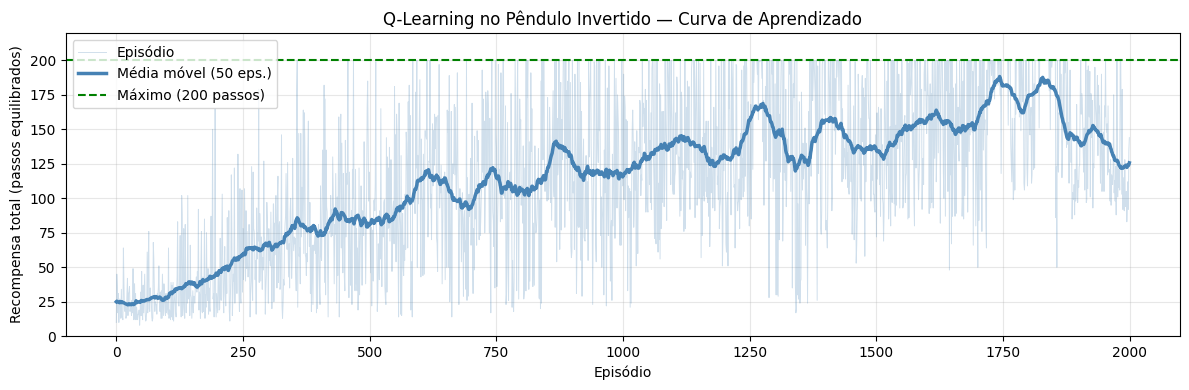

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(rewards, color="steelblue", alpha=0.25, linewidth=0.7, label="Episódio")
ax.plot(smooth(rewards, window=50), color="steelblue", linewidth=2.5, label="Média móvel (50 eps.)")
ax.axhline(200, color="green", linestyle="--", linewidth=1.5, label="Máximo (200 passos)")

ax.set_xlabel("Episódio")
ax.set_ylabel("Recompensa total (passos equilibrados)")
ax.set_title("Q-Learning no Pêndulo Invertido — Curva de Aprendizado")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 220)

plt.tight_layout()
plt.show()

## Avaliação da Política Aprendida

Avaliamos a política **puramente gulosa** (sem exploração ε) em 100 episódios independentes. Um agente treinado com sucesso deve atingir consistentemente os 200 passos máximos.

In [5]:
eval_env = InvertedPendulum(n_bins=10, max_steps=200, seed=99)
mean_r, std_r = evaluate_policy(eval_env, result, episodes=100, max_steps=200, seed=0)

print(f"Avaliação (política gulosa, 100 episódios):")
print(f"  Recompensa média : {mean_r:.2f} ± {std_r:.2f} passos")
print(f"  Taxa de sucesso  : {mean_r / 200 * 100:.1f}% (200 = vitória)")

Avaliação (política gulosa, 100 episódios):
  Recompensa média : 118.27 ± 26.93 passos
  Taxa de sucesso  : 59.1% (200 = vitória)


## Visualização de um Episódio Completo

Simulamos um episódio completo com a política aprendida e visualizamos a trajetória do ângulo do pêndulo e da posição do carrinho ao longo do tempo.

Duração do episódio: 137 passos
Ângulo máximo atingido: 10.88°


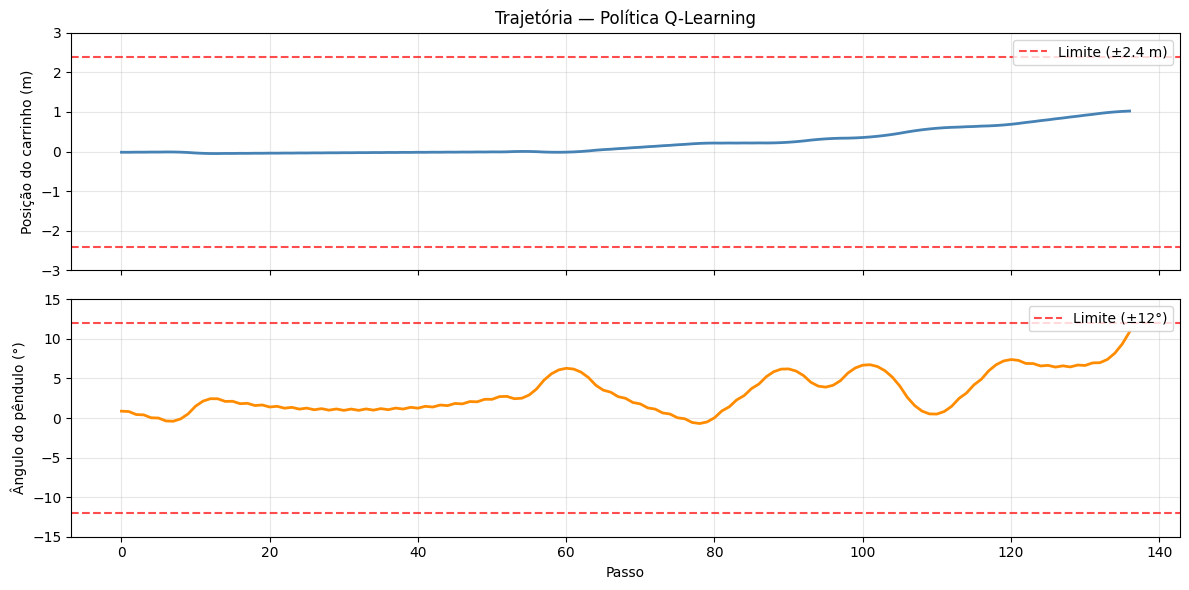

In [6]:
from structures.algorithms.rl_solver import greedy_action

# Simula um episódio com a política aprendida
sim_env = InvertedPendulum(n_bins=10, max_steps=200, seed=7)
state = sim_env.reset()

trajectory = []
actions_taken = []

for step in range(200):
    x, xdot, theta, thetadot = sim_env.continuous_state
    trajectory.append((x, math.degrees(theta), step))

    action = greedy_action(result, sim_env, state)
    actions_taken.append(action)
    state, reward, done = sim_env.step(action)

    if done:
        break

xs     = [t[0] for t in trajectory]
thetas = [t[1] for t in trajectory]
steps  = [t[2] for t in trajectory]

print(f"Duração do episódio: {len(trajectory)} passos")
print(f"Ângulo máximo atingido: {max(abs(th) for th in thetas):.2f}°")

# Gráfico das trajetórias
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Posição do carrinho
axes[0].plot(steps, xs, color="steelblue", linewidth=2)
axes[0].axhline(2.4, color="red", linestyle="--", alpha=0.7, label="Limite (±2.4 m)")
axes[0].axhline(-2.4, color="red", linestyle="--", alpha=0.7)
axes[0].set_ylabel("Posição do carrinho (m)")
axes[0].set_title("Trajetória — Política Q-Learning")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-3, 3)

# Ângulo do pêndulo
axes[1].plot(steps, thetas, color="darkorange", linewidth=2)
axes[1].axhline(12, color="red", linestyle="--", alpha=0.7, label="Limite (±12°)")
axes[1].axhline(-12, color="red", linestyle="--", alpha=0.7)
axes[1].set_ylabel("Ângulo do pêndulo (°)")
axes[1].set_xlabel("Passo")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-15, 15)

plt.tight_layout()
plt.show()

## Snapshots Visuais do Pêndulo

Visualizamos o pêndulo em instantes selecionados do episódio, mostrando a posição do carrinho e a inclinação do pêndulo.

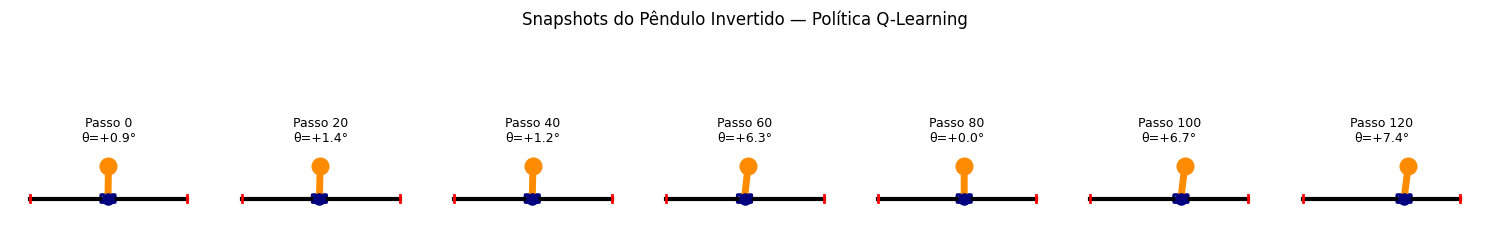

In [7]:
def draw_pendulum(ax, x_cart, theta_rad, title=""):
    """Desenha o carrinho e o pêndulo numa figura matplotlib."""
    # Trilho
    ax.plot([-2.4, 2.4], [0, 0], "k-", linewidth=3)
    ax.plot([-2.4, -2.4], [-0.1, 0.1], "r-", linewidth=2)
    ax.plot([ 2.4,  2.4], [-0.1, 0.1], "r-", linewidth=2)

    # Carrinho
    cart = patches.FancyBboxPatch(
        (x_cart - 0.2, -0.1), 0.4, 0.2,
        boxstyle="round,pad=0.02",
        facecolor="steelblue", edgecolor="navy", linewidth=2
    )
    ax.add_patch(cart)

    # Pêndulo
    pole_len = 1.0   # comprimento visual
    px = x_cart + pole_len * math.sin(theta_rad)
    py = pole_len * math.cos(theta_rad)
    ax.plot([x_cart, px], [0, py], color="darkorange", linewidth=5)
    ax.plot(px, py, "o", color="darkorange", markersize=12)
    ax.plot(x_cart, 0, "o", color="navy", markersize=8)

    ax.set_xlim(-3, 3)
    ax.set_ylim(-0.5, 1.5)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=9)
    ax.axis("off")


# Re-simula para capturar estados contínuos
sim_env2 = InvertedPendulum(n_bins=10, max_steps=200, seed=7)
state = sim_env2.reset()
snapshots = []

for step in range(200):
    x, _, theta, _ = sim_env2.continuous_state
    if step % 20 == 0:
        snapshots.append((step, x, theta))
    action = greedy_action(result, sim_env2, state)
    state, _, done = sim_env2.step(action)
    if done:
        break

n_snap = min(len(snapshots), 8)
fig, axes = plt.subplots(1, n_snap, figsize=(15, 3))
if n_snap == 1:
    axes = [axes]

for ax, (step, x, theta) in zip(axes, snapshots[:n_snap]):
    draw_pendulum(ax, x, theta, title=f"Passo {step}\nθ={math.degrees(theta):+.1f}°")

fig.suptitle("Snapshots do Pêndulo Invertido — Política Q-Learning", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Efeito do Número de Bins na Aprendizagem

O número de bins é um hiperparâmetro crítico:

- **Poucos bins** (ex: 5): aproximação muito grosseira — agente pode não aprender
- **Muitos bins** (ex: 20): melhor precisão, mas mais estados a explorar — aprendizado mais lento
- **Moderado** (ex: 10): balanço adequado para o CartPole

Comparamos o desempenho com diferentes granularidades de discretização.

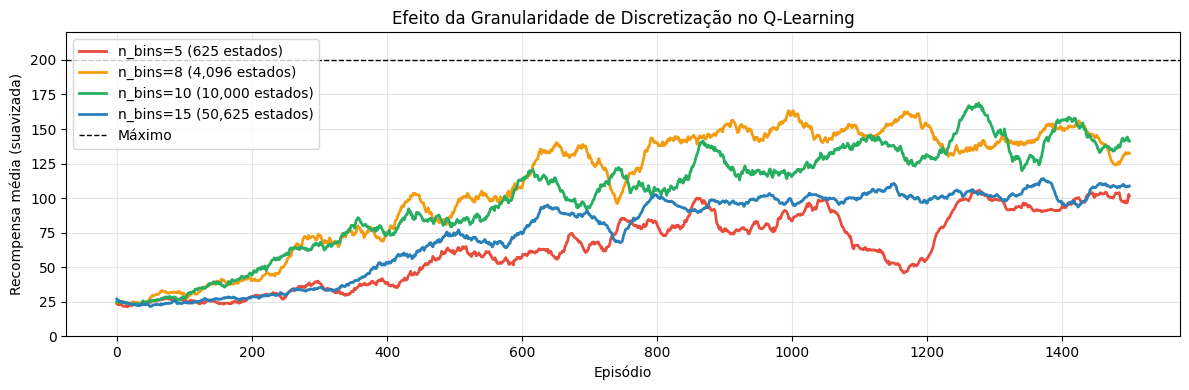

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))

colors = ["#e74c3c", "#f39c12", "#27ae60", "#2980b9"]

for bins, color in zip([5, 8, 10, 15], colors):
    r = q_learning(
        InvertedPendulum(n_bins=bins, max_steps=200, seed=0),
        episodes=1500,
        alpha=0.1,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_end=0.01,
        epsilon_decay=0.997,
        max_steps=200,
        seed=42
    )
    ax.plot(smooth(r.episode_rewards, window=50), color=color,
            linewidth=2, label=f"n_bins={bins} ({bins**4:,} estados)")

ax.axhline(200, color="black", linestyle="--", linewidth=1, label="Máximo")
ax.set_xlabel("Episódio")
ax.set_ylabel("Recompensa média (suavizada)")
ax.set_title("Efeito da Granularidade de Discretização no Q-Learning")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 220)

plt.tight_layout()
plt.show()

## Conclusões

### O que aprendemos

1. **Q-learning tabular funciona em espaços contínuos** desde que o estado seja discretizado adequadamente

2. **Discretização é uma aproximação** que introduz um trade-off:
   - Granularidade fina → mais estados, aprendizado mais lento
   - Granularidade grossa → menos estados, política menos precisa

3. **O CartPole é um marco** na história do RL — demonstra que algoritmos simples conseguem resolver problemas de controle não-triviais

### Limitações e Extensões

| Limitação | Solução Moderna |
|---|---|
| Discretização manual | Redes neurais (Deep Q-Network — DQN) |
| Q-table cresce exponencialmente | Aproximação de função (DQN, A3C, PPO) |
| Somente ações discretas | Métodos de política (DDPG, SAC) |
| Eficiência amostral baixa | Experience Replay, Target Networks |

O **Deep Q-Network (DQN)** de Mnih et al. (2015) resolveu o problema de escala substituindo a Q-table por uma rede neural, permitindo aplicar RL diretamente a pixels de jogos Atari — um marco histórico da IA moderna.